## Business Problem

## Data Information

In [1]:
import pandas as pd

# Define the data
data = {
    'Column': ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
               'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
               'stays_in_week_nights', 'adults,children,babies', 'meal', 'country',
               'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
               'previous_bookings_not_canceled', 'reserved_room_type, assigned_room_type',
               'booking_changes', 'deposit_type', 'agent,company', 'days_in_waiting_list',
               'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests',
               'reservation_status', 'reservation_status_date'],
    'Information': ['Indicates the type of hotel, where all reservations belong to the "Resort Hotel" type in this case.',
                    'Indicates whether the reservation is canceled or not (0 for reservations that are not canceled and 1 for reservations that are canceled).',
                    "The amount of time between the reservation date and the customer's arrival date at the hotel.",
                    'The year the customer arrives at the hotel.', 'The month the customer arrives at the hotel.',
                    "The week number of the customer's arrival at the hotel.",
                    'The day of the month the customer arrives at the hotel.',
                    'The number of weekend nights the customer stays.', 'The number of week nights the customer stays.',
                    'The number of adults, children, and babies in the reservation.',
                    'Describes what type of meal was booked (Breakfast only, Half board, Full board, or Undefined/SC – no meal package).', 'The country of origin of the customer.',
                    'Shows various market segments that individuals belong to when making reservations (e.g., Online Travel Agents, Offline Travel Agents, Corporate clients).',
                    'Specifies different channels through which bookings were made (e.g., online travel agencies, direct bookings with hotels/tour operators, corporate arrangements).',
                    'Indicates whether the guest is a repeated visitor (0=not repeated guest, 1=repeated guest).',
                    'The number of previous bookings that were canceled by the customer.',
                    'The number of previous bookings that were not canceled by the customer.',
                    'The type of room that was reserved and the type of room assigned to the customer.',
                    'The number of changes made to the reservation.', 'The type of deposit for the reservation.',
                    'Customer information regarding the agent and company.',
                    'The number of days the reservation was on the waiting list.',
                    'The type of customer (Transient, Contract, Group, Transient-Party).',
                    'The average daily rate for this reservation.', 'The number of required parking spaces.',
                    'The number of special requests.', 'The reservation status (Check-Out or Canceled).',
                    'The date when the reservation status was recorded.']
}

# Create the DataFrame
df_info = pd.DataFrame(data)

# Display the DataFrame
df_info

pd.options.display.max_columns = None

df_info

,Column,Information
0,hotel,"Indicates the type of hotel, where all reserva..."
1,is_canceled,Indicates whether the reservation is canceled ...
2,lead_time,The amount of time between the reservation dat...
3,arrival_date_year,The year the customer arrives at the hotel.
4,arrival_date_month,The month the customer arrives at the hotel.
5,arrival_date_week_number,The week number of the customer's arrival at t...
6,arrival_date_day_of_month,The day of the month the customer arrives at t...
7,stays_in_weekend_nights,The number of weekend nights the customer stays.
8,stays_in_week_nights,The number of week nights the customer stays.
9,"adults,children,babies","The number of adults, children, and babies in ..."


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

## Reading file

In [2]:
df_hotel_booking = pd.read_csv('hotel_booking.csv')

In [3]:
# Making copy of Original Dataset
df = df_hotel_booking

In [4]:
df.sample(n=5,random_state=100).T

,47013,70144,28651,57362,88743
hotel,City Hotel,City Hotel,Resort Hotel,City Hotel,City Hotel
is_canceled,1,1,0,1,0
lead_time,13,2,3,59,8
arrival_date_year,2016,2017,2016,2016,2016
arrival_date_month,February,June,October,September,May
arrival_date_week_number,6,24,41,39,20
arrival_date_day_of_month,3,11,8,24,10
stays_in_weekend_nights,8,1,0,1,0
stays_in_week_nights,21,0,1,1,2
adults,1,2,2,3,2


## Data Understanding

In [5]:
df.shape

(119390, 36)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
# Checking datatypes of all variables
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [12]:
# Description of numeric variables
df.select_dtypes(include=np.number).describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [13]:
# Description of categorical variables
df.select_dtypes(exclude=np.number).describe().T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [14]:
# Checking no. of categories and count of categories in each categorical column
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print('-------------------------------------')

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
-------------------------------------
arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64
-------------------------------------
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64
-------------------------------------
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64
-------------------------------------
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefin

In [15]:
# Checking duplicate values in dataset
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card


In [7]:
# reservation_status,name,email,phone-number,credit_card variables will add moise to the data, 
# so can be dropped from further analysis.
# Also columns reservation_status_date can be dropped since we already have lead_time column giving same information.
df.drop(['phone-number','email','name','credit_card','reservation_status','reservation_status_date'],axis=1,inplace=True)

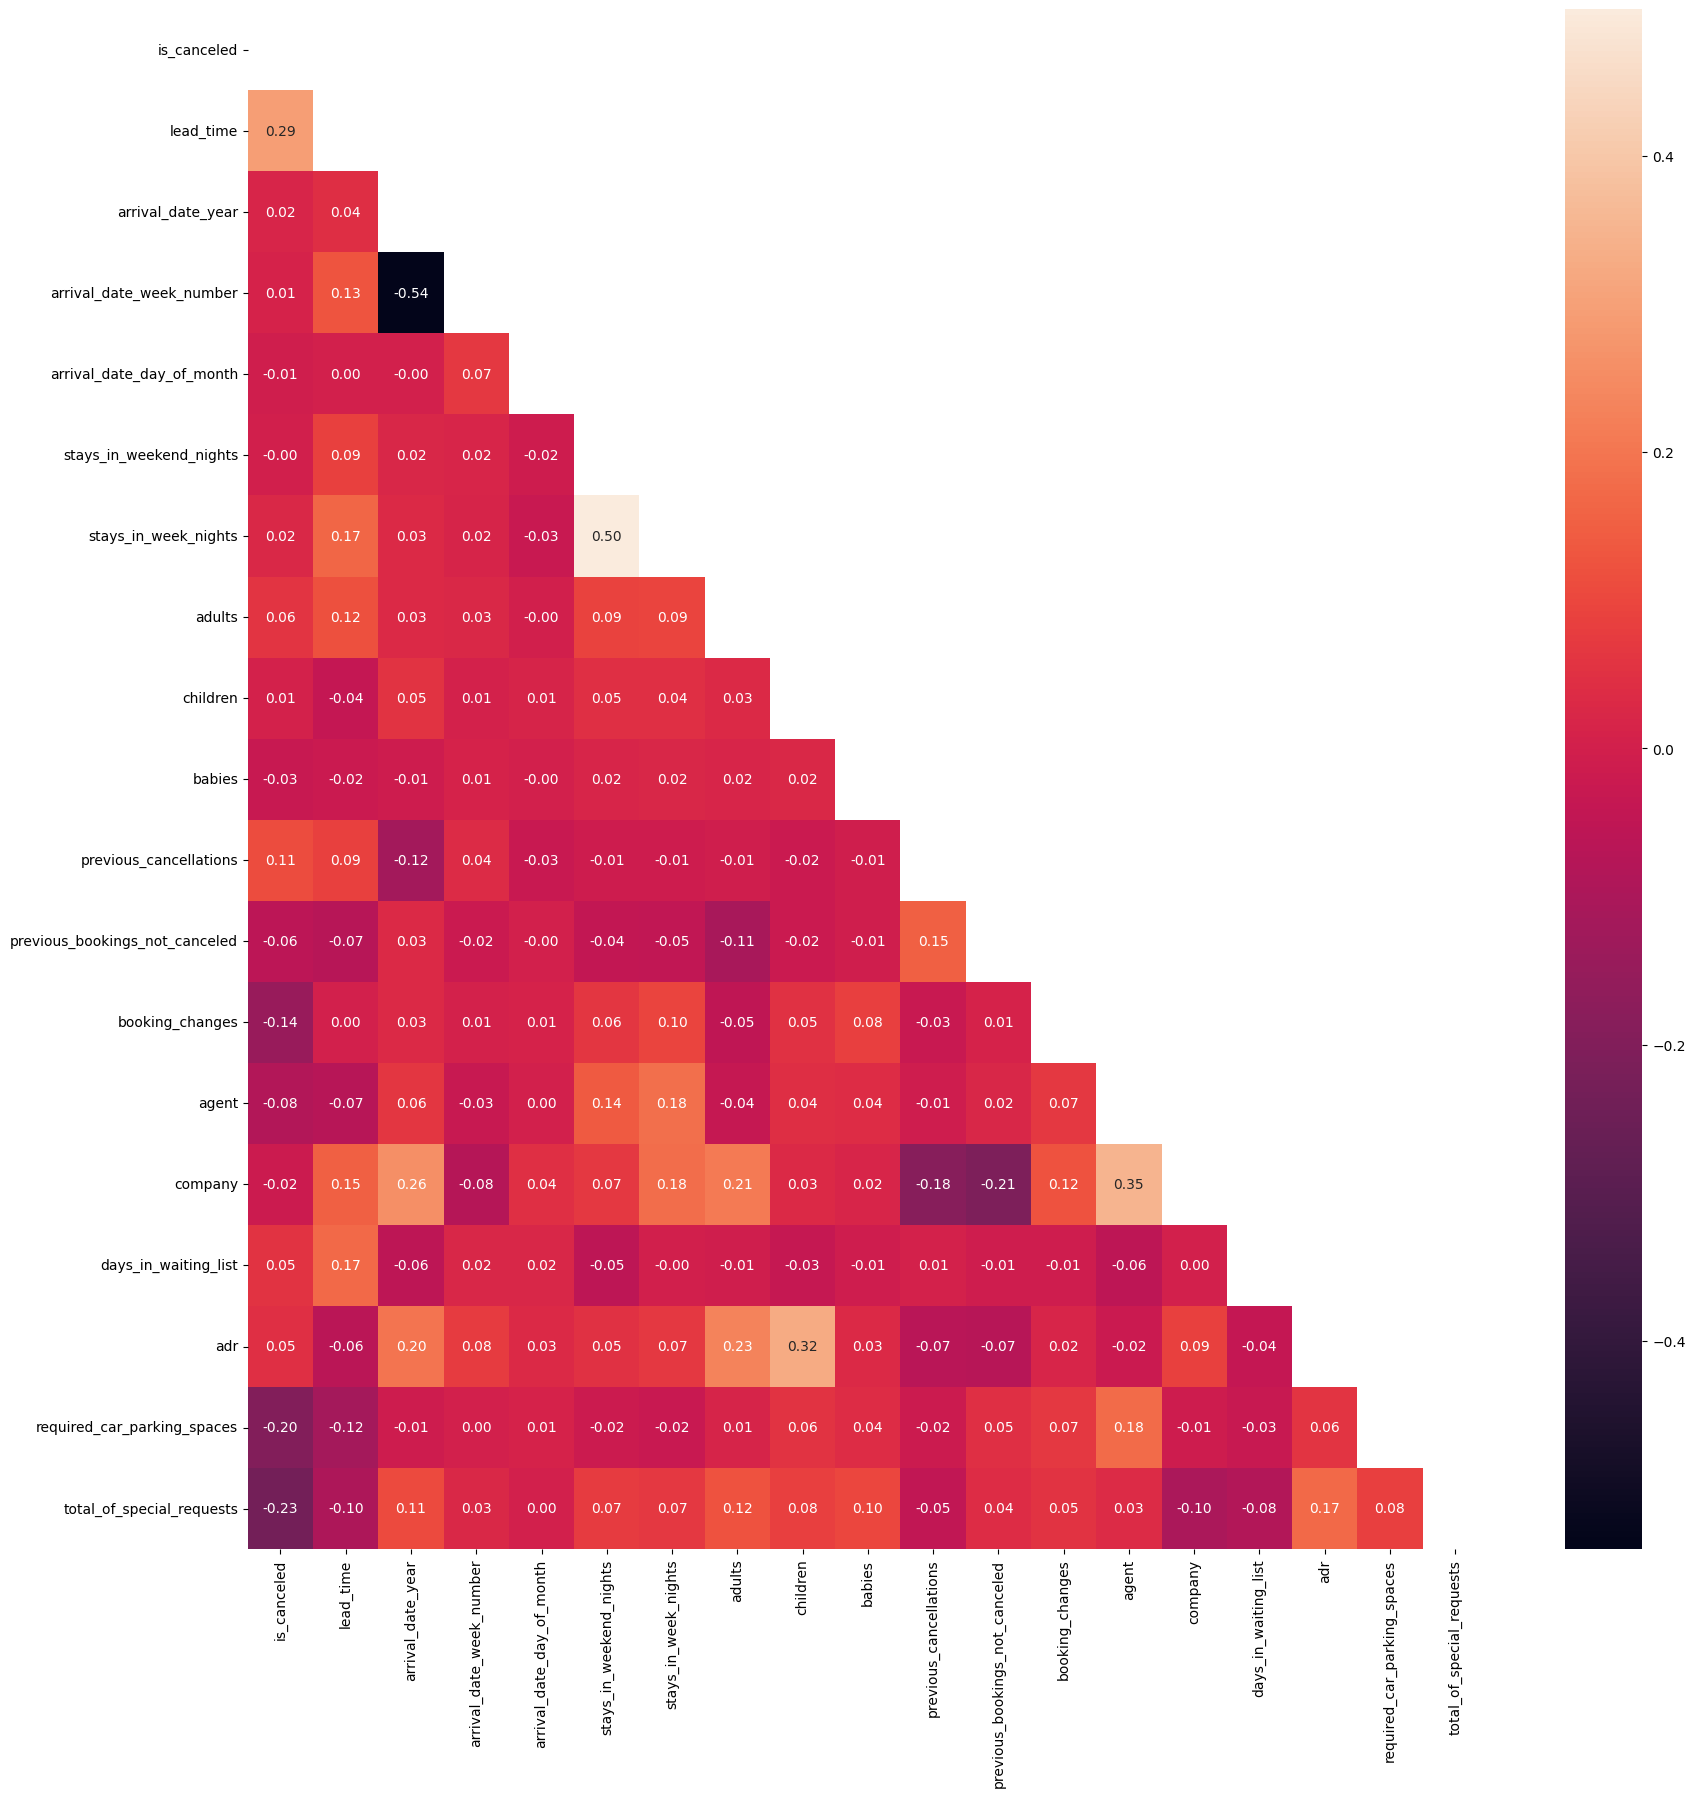

In [17]:
# Checking correaltion between all numerical columns.
# removing is_repeated_guest volumn from heatmap as it is categorical encoded numrical column.
mask = np.triu(np.ones_like(df.drop('is_repeated_guest',axis=1).select_dtypes(exclude='object').corr()))
plt.subplots(figsize=(20,20))
sns.heatmap(df.drop('is_repeated_guest',axis=1).select_dtypes(exclude='object').corr(),annot=True,fmt='.2f',mask=mask)
plt.show()

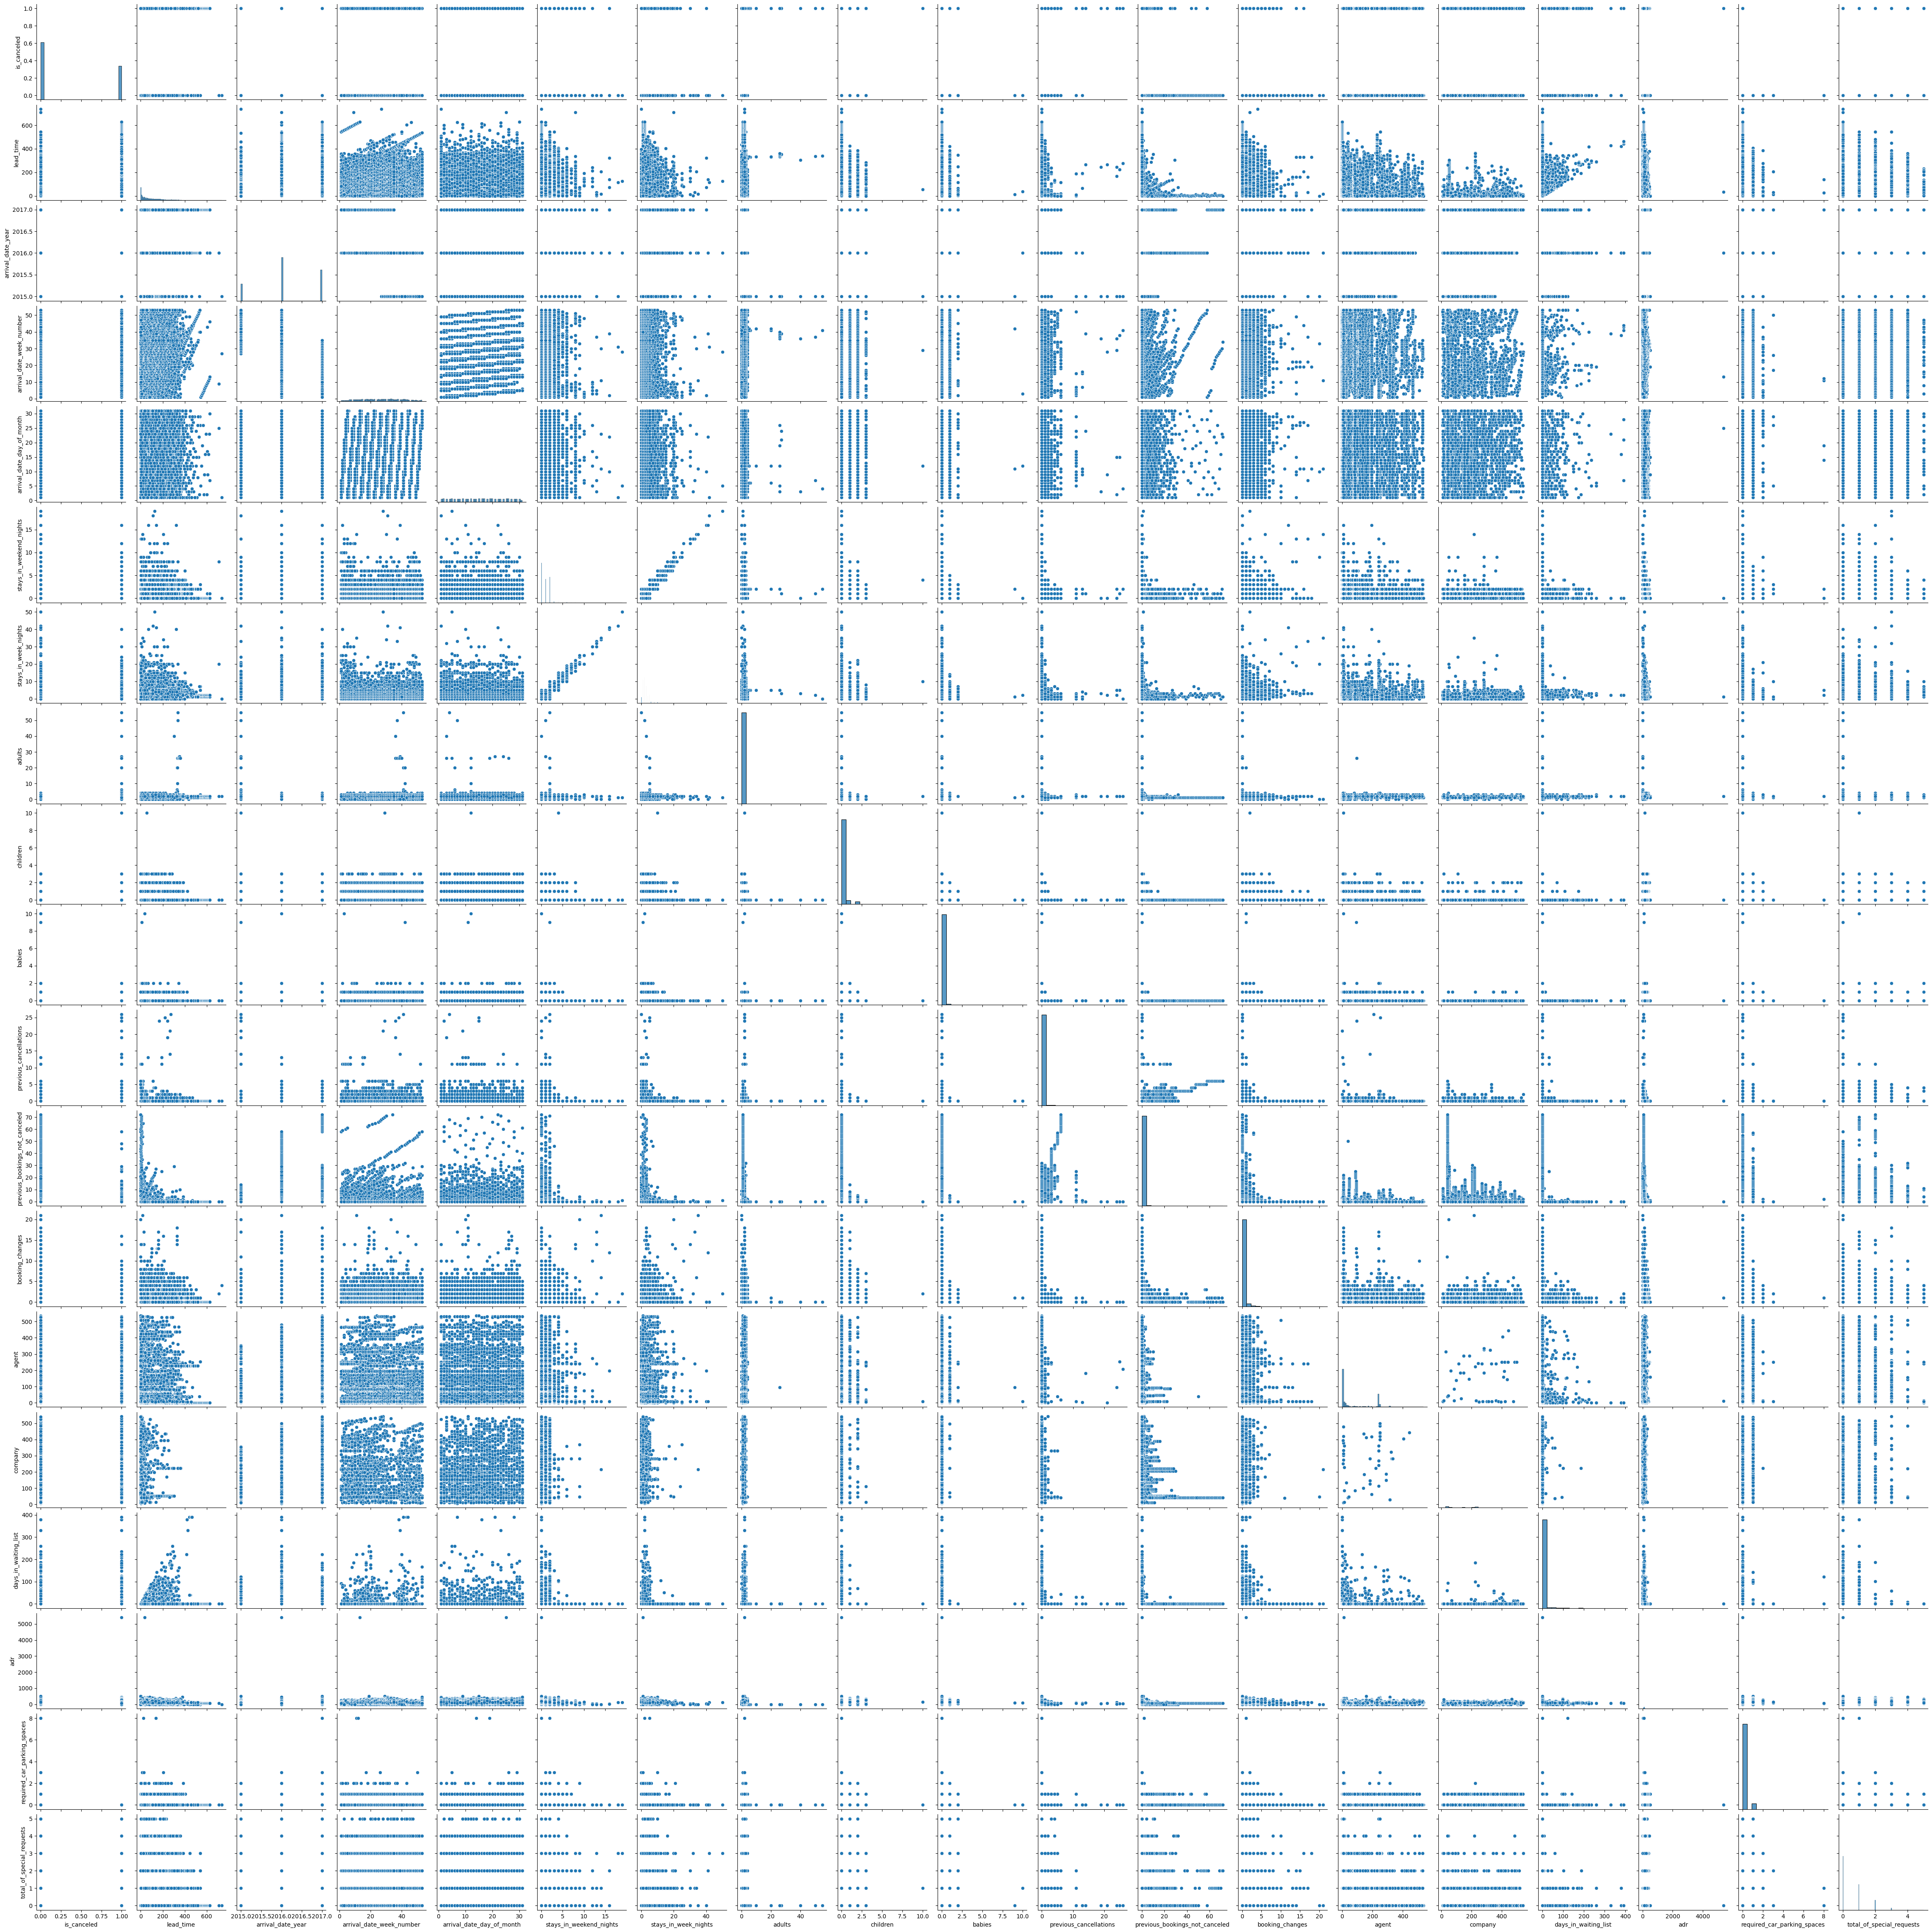

In [23]:
sns.pairplot(df.drop('is_repeated_guest',axis=1).select_dtypes(include=np.number))

In [13]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

# Null Values

In [18]:
df.isnull().sum().sort_values(ascending = False)

company                           112593
agent                              16340
country                              488
children                               4
hotel                                  0
is_repeated_guest                      0
required_car_parking_spaces            0
adr                                    0
customer_type                          0
days_in_waiting_list                   0
deposit_type                           0
booking_changes                        0
assigned_room_type                     0
reserved_room_type                     0
previous_bookings_not_canceled         0
previous_cancellations                 0
distribution_channel                   0
is_canceled                            0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_nights                   0
stays_in_weekend_nights                0
arrival_date_day

In [7]:
df.isnull().sum().sort_values(ascending = False)/len(df)*100

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
hotel                              0.000000
is_repeated_guest                  0.000000
required_car_parking_spaces        0.000000
adr                                0.000000
customer_type                      0.000000
days_in_waiting_list               0.000000
deposit_type                       0.000000
booking_changes                    0.000000
assigned_room_type                 0.000000
reserved_room_type                 0.000000
previous_bookings_not_canceled     0.000000
previous_cancellations             0.000000
distribution_channel               0.000000
is_canceled                        0.000000
market_segment                     0.000000
meal                               0.000000
babies                             0.000000
adults                             0.000000
stays_in_week_nights            

### Null Value Imputation

In [8]:
# There is no point to go with company column it contains near about total null values. so dropping the variable
# Also agent column will mostly contain agents of Europe thus it will not provide much information in analysis.
df.drop(['company','agent'],axis=1,inplace=True)

In [20]:
df['country'].value_counts()

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ...  
DJI        1
BWA        1
HND        1
VGB        1
NAM        1
Name: count, Length: 177, dtype: int64

In [9]:
# we can impute the null values of country column by mode because dtype of country column is object
print('Mode value of the country variable is ',df['country'].mode())
#Imputation
df['country']= df['country'].fillna('PRT')

Mode value of the country variable is  0    PRT
Name: country, dtype: object


In [10]:
# we can impute the null values of children column by median because it contains outliers
df['children'] = df['children'].fillna(df['children'].median())

In [23]:
df.isnull().sum().sum()

0

# Outliers

In [13]:
# Null values removed new numerical and categorical dataframe created.

In [11]:
df_num = df.select_dtypes(include=np.number)
df_num.drop('is_repeated_guest',axis=1,inplace=True)

In [12]:
df_cat = df.select_dtypes(exclude=np.number)
df_cat['is_repeated_guest'] = df['is_repeated_guest']

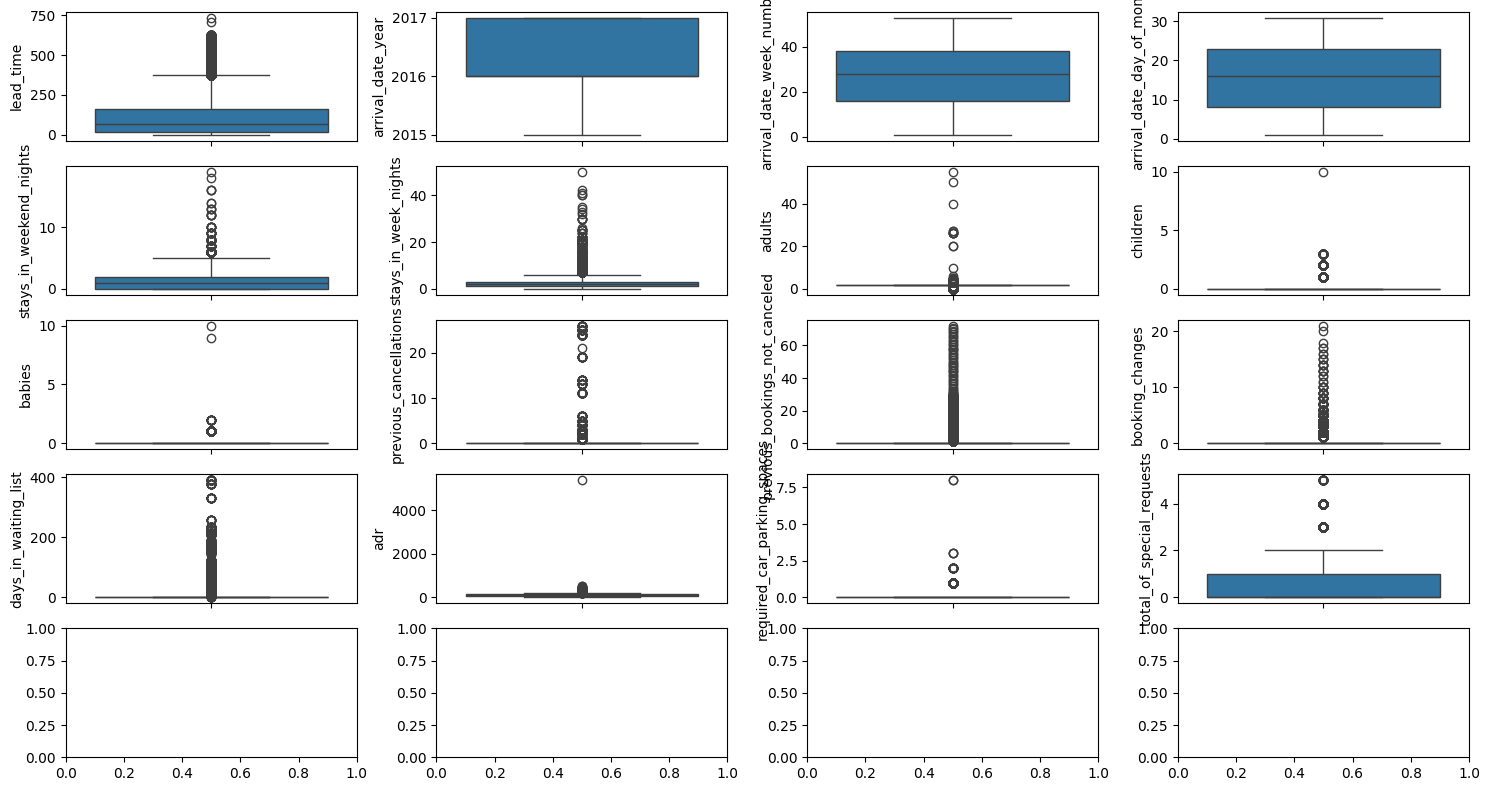

In [16]:
fig,ax = plt.subplots(nrows=5,ncols=4,figsize = (15,8))
for variable,subplot in zip(df_num.drop('is_canceled',axis=1).columns,ax.flatten()):
    sns.boxplot(df_num[variable],ax=subplot)
plt.tight_layout()
plt.show()

### Outlier Treatment

- In our analysis of the hotel cancellation dataset, we found numerous outliers. Instead of removing or capping these outliers, we've chosen to keep them. This decision is based on the understanding that outliers can contain valuable information that contributes to the overall understanding of the data. Removing them could lead to a significant loss of data and potentially valuable insights.

- By retaining the outliers, we aim to build more robust models that reflect real-world scenarios and capture a wider range of patterns. Rather than removing outliers, we'll explore methods to manage their impact, ensuring that our analysis remains comprehensive and insightful.

## Feature Engineering

To handle the country column with 177 unique values without using dummy encoding, you can categorize countries by their continents. This involves creating a mapping of each country to its corresponding continent and then applying this mapping to your DataFrame. This approach reduces dimensionality and retains important geographical information. After mapping, you can use encoding techniques like one-hot encoding or label encoding on the continent column as needed for your analysis or machine learning model. This method streamlines the data while maintaining its relevance and interpretability.

In [13]:
africa = ['AGO', 'MOZ', 'ZAF', 'ZMB', 'CPV', 'ZWE', 'DZA', 'NGA', 'SEN', 'EGY', 'TUN', 'CIV', 'COM', 'UGA', 'BDI', 'RWA', 'DJI', 'STP', 'ETH', 'TGO', 'KEN', 'GNB', 'MLI', 'NAM', 'BFA', 'LBY', 'MWI', 'MDG', 'GAB', 'GHA', 'TZA', 'SLE']
asia = ['ARE', 'IND', 'CHN', 'JPN', 'KOR', 'IRN', 'KAZ', 'PAK', 'IDN', 'PHL', 'THA', 'LBN', 'KWT', 'BHR', 'ARM', 'LKA', 'MYS', 'SGP', 'VNM', 'UZB', 'NPL', 'MAC', 'TJK', 'IRQ', 'KHM', 'SYR', 'HKG', 'JOR', 'PSE', 'KOR', 'LAO', 'MMR']
europe = ['PRT', 'GBR', 'ESP', 'IRL', 'FRA', 'ROU', 'NOR', 'POL', 'DEU', 'BEL', 'CHE', 'GRC', 'ITA', 'NLD', 'DNK', 'RUS', 'SWE', 'EST', 'CZE', 'FIN', 'BWA', 'LUX', 'SVN', 'ALB', 'MDA', 'SRB', 'AUT', 'BLR', 'LTU', 'TUR', 'HRV', 'HUN', 'LVA', 'SMR', 'ISL', 'SVK', 'GIB', 'AND', 'JEY', 'GGY', 'LIE', 'MCO', 'MNE', 'FRO']
north_america = ['USA', 'MEX', 'PRI', 'CAN', 'DMA', 'BLZ', 'ATG', 'SLV', 'KNA', 'VGB', 'HTI', 'TTO', 'GRD', 'CYM', 'BHS', 'ABW', 'AIA', 'GUY', 'LCA', 'CRI', 'HND', 'PAN', 'NIC', 'BRB']
south_america = ['ARG', 'BRA', 'CHL', 'COL', 'URY', 'PER', 'VEN', 'GUF', 'PRY', 'BOL', 'SUR']
oceania = ['AUS', 'NZL', 'FJI', 'PNG', 'PYF', 'NCL', 'KIR']
antarctica = ['ATA']

def get_continent(country_code):
    if country_code in africa:
        return 'Africa'
    elif country_code in asia:
        return 'Asia'
    elif country_code in europe:
        return 'Europe'
    elif country_code in north_america:
        return 'North America'
    elif country_code in south_america:
        return 'South America'
    elif country_code in oceania:
        return 'Oceania'
    elif country_code in antarctica:
        return 'Antarctica'
    else:
        return 'Unknown'

df_cat['continent'] = df_cat['country'].apply(get_continent)

In [14]:
df_cat['continent'].value_counts()

continent
Europe           108377
Unknown            2738
South America      2680
North America      2241
Asia               2026
Africa              822
Oceania             504
Antarctica            2
Name: count, dtype: int64

In [15]:
df_cat.drop('country',axis=1,inplace=True)

In [16]:
# creating new dataframe for Data Analysis with removing outliers from numerical columns and treating null values.
df1 = pd.concat([df.select_dtypes(include='object'),df_num,df_cat['continent']],axis=1)
df1.head()

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,...,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,continent
0,Resort Hotel,July,BB,PRT,Direct,Direct,C,C,No Deposit,Transient,...,0.0,0,0,0,3,0,0.0,0,0,Europe
1,Resort Hotel,July,BB,PRT,Direct,Direct,C,C,No Deposit,Transient,...,0.0,0,0,0,4,0,0.0,0,0,Europe
2,Resort Hotel,July,BB,GBR,Direct,Direct,A,C,No Deposit,Transient,...,0.0,0,0,0,0,0,75.0,0,0,Europe
3,Resort Hotel,July,BB,GBR,Corporate,Corporate,A,A,No Deposit,Transient,...,0.0,0,0,0,0,0,75.0,0,0,Europe
4,Resort Hotel,July,BB,GBR,Online TA,TA/TO,A,A,No Deposit,Transient,...,0.0,0,0,0,0,0,98.0,0,1,Europe


## Data Analysis

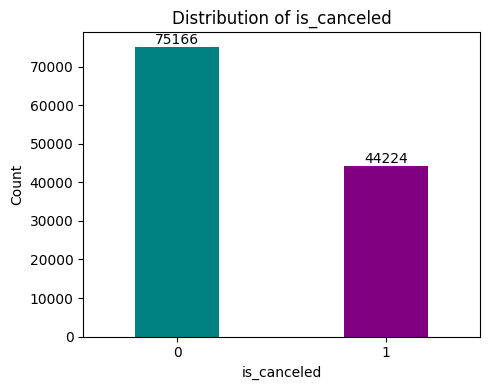

In [30]:
plt.figure(figsize=(5, 4))
df1['is_canceled'].value_counts().plot(kind='bar', color=['teal', 'purple'], width=0.4)
plt.title('Distribution of is_canceled')
plt.xlabel('is_canceled')
plt.ylabel('Count')

for i, count in enumerate(df1['is_canceled'].value_counts()):
    plt.text(i, count + 0.2, str(count), ha='center', va='bottom')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The chart conveys the information that the number of bookings that were not canceled is greater than the number of bookings that were canceled.

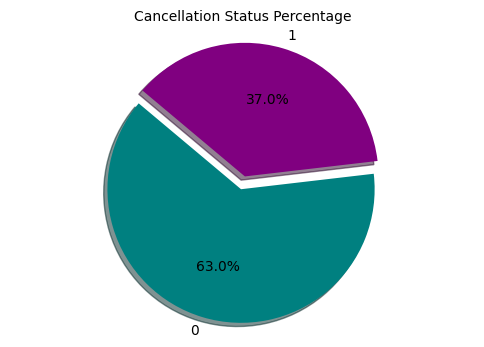

In [31]:
# Calculate cancellation percentages
cancel_percentages = df1['is_canceled'].value_counts() / df1['is_canceled'].count() * 100

# Set explode values for the slices
explode = (0.1, 0)

# Define colors for the pie chart
colors = ['teal', 'purple']

# Set font size for labels and percentages
plt.rcParams['font.size'] = 10

# Plot the pie chart
plt.figure(figsize=(6,4))
plt.pie(cancel_percentages, labels=cancel_percentages.index, autopct='%1.1f%%', shadow=True, explode=explode, colors=colors, startangle=140)

# Set the title
plt.title('Cancellation Status Percentage', fontsize=10)

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')

# Show the plot
plt.show()

The chart conveys the information that the number of bookings that were not canceled is greater than the number of bookings that were canceled

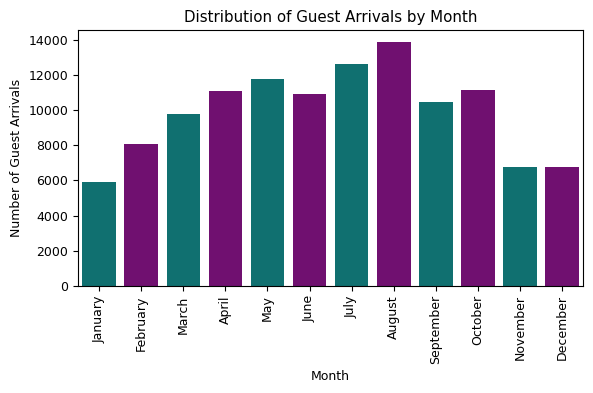

Months with above-average arrivals: ['April', 'May', 'June', 'July', 'August', 'September', 'October']
Months with below-average arrivals: ['January', 'February', 'March', 'November', 'December']


In [32]:
months_order = ["January", "February", "March", "April", "May", "June", 
                "July", "August", "September", "October", "November", "December"]
df1['arrival_date_month'] = pd.Categorical(df1['arrival_date_month'], categories=months_order, ordered=True)

# Group data by month and calculate the mean of guest arrivals
monthly_guest_arrivals = df1.groupby('arrival_date_month')['is_canceled'].count()

# Set font size for labels and percentages
plt.rcParams['font.size'] = 9
# Creating the bar plot for monthly guest arrivals
plt.figure(figsize=(6,4))
sns.barplot(x=monthly_guest_arrivals.index, y=monthly_guest_arrivals.values, palette=['teal', 'purple'])
plt.xlabel("Month")
plt.ylabel("Number of Guest Arrivals")
plt.title("Distribution of Guest Arrivals by Month")
plt.xticks(rotation=90)
plt.tight_layout()

# Displaying the plot
plt.show()

# Calculate the average number of arrivals per month
average_arrivals_per_month = monthly_guest_arrivals.mean()

# Create a list of months with above-average and below-average arrivals
above_average_months = monthly_guest_arrivals[monthly_guest_arrivals > average_arrivals_per_month].index
below_average_months = monthly_guest_arrivals[monthly_guest_arrivals <= average_arrivals_per_month].index
print(f"Months with above-average arrivals: {list(above_average_months)}")
print(f"Months with below-average arrivals: {list(below_average_months)}")

Yes, according to the provided output, the months with the highest guest arrivals and the months with the lowest guest arrivals are as follows:

Months with the highest guest arrivals:

July
August
Months with the lowest guest arrivals:

January
With this distribution, it appears that summer and autumn months (from April to October) have the highest number of guest arrivals, while winter months (January, February, March, and December) have the lowest number of guest arrivals.

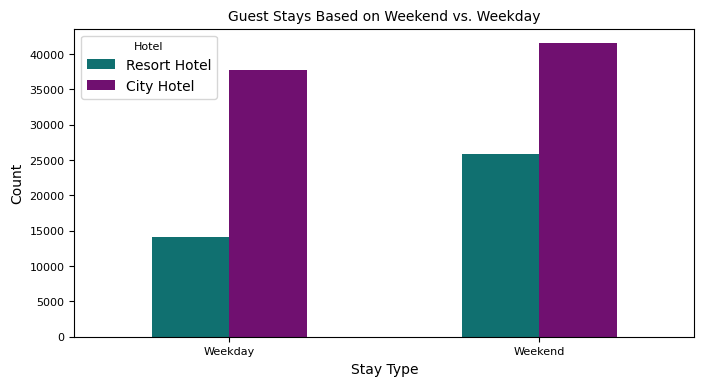

In [33]:
# Create a new column 'stay_type' to categorize stays as 'Weekend' or 'Weekday'
df1['stay_type'] = df1.apply(lambda row: 'Weekend' if row['stays_in_weekend_nights'] > 0 else 'Weekday', axis=1)

# Set font size for labels and percentages
plt.rcParams['font.size'] = 8

# Create a bar plot
plt.figure(figsize=(8,4))
sns.countplot(data=df1, x='stay_type', hue='hotel', palette=["teal", "purple"],width=0.5)
plt.title('Guest Stays Based on Weekend vs. Weekday', fontsize=10)
plt.xlabel('Stay Type', fontsize=10)  # Adjust font size to 16
plt.ylabel('Count', fontsize=10)
plt.legend(title='Hotel', fontsize=10)
plt.show()

In summary, guests prefer shorter weekend getaways (1-2 nights) and exhibit a more varied distribution of stays on weekdays (1-5 nights).

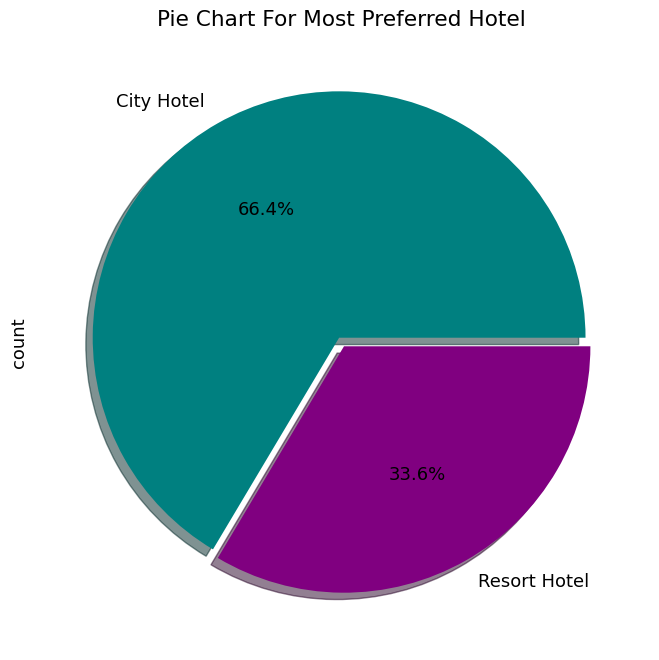

In [34]:
# Create a pie chart for the most preferred hotel
colors = ["teal", "purple"]
explode = [0.02, 0.02]

# Set font size for labels and percentages
plt.rcParams['font.size'] = 13

plt.figure(figsize=(10, 8))
df1['hotel'].value_counts().plot.pie(explode=explode, autopct='%1.1f%%', shadow=True, figsize=(10, 8), colors=colors)
plt.title("Pie Chart For Most Preferred Hotel")
plt.show()

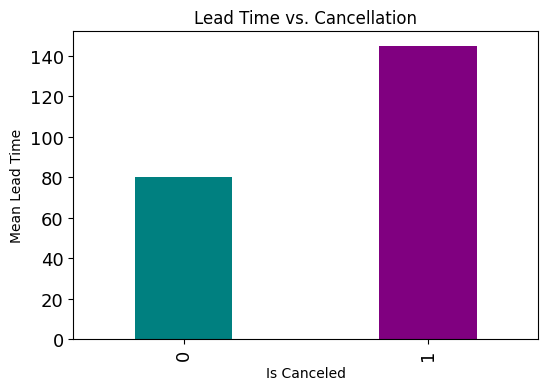

In [35]:
plt.figure(figsize=(6, 4))
mean_lead_time = df1.groupby('is_canceled')['lead_time'].mean()
mean_lead_time.plot(kind='bar', color=['teal', 'purple'], width=0.4)
plt.title('Lead Time vs. Cancellation', fontsize=12)
plt.xlabel('Is Canceled', fontsize=10)
plt.ylabel('Mean Lead Time', fontsize=10)
plt.show()

Lead Time cancellation of cancelled bookings are high

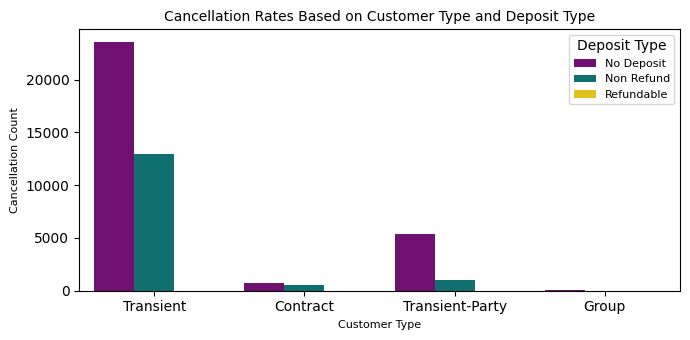

In [36]:
# Filter only the cancelled reservations
cancelled_df = df1[df1['is_canceled'] == 1]

# Set font size for labels and percentages
plt.rcParams['font.size'] = 10

# Create the plot with smaller size
plt.figure(figsize=(7, 3.5))
sns.countplot(data=cancelled_df, x='customer_type', hue='deposit_type', palette=["purple", "teal", "gold"])
plt.title('Cancellation Rates Based on Customer Type and Deposit Type', fontsize=10)
plt.xlabel('Customer Type', fontsize=8)
plt.ylabel('Cancellation Count', fontsize=8)
plt.legend(title='Deposit Type', fontsize=8)
plt.tight_layout()

# Show the plot
plt.show()

Cancellation Analysis: Key Insights

Analyzing cancelled reservations revealed that the average lead time was approximately 145 days. The most common customer type among cancellations was "Transient," indicating individual bookings without contractual obligations had a higher cancellation rate. Additionally, "No Deposit" was the prevalent deposit type for these reservations, suggesting a correlation between the absence of upfront payments and higher cancellation rates. These insights highlight critical trends in guest booking behavior and can guide hotels in refining their booking strategies and policies to reduce cancellations and enhance the guest experience.

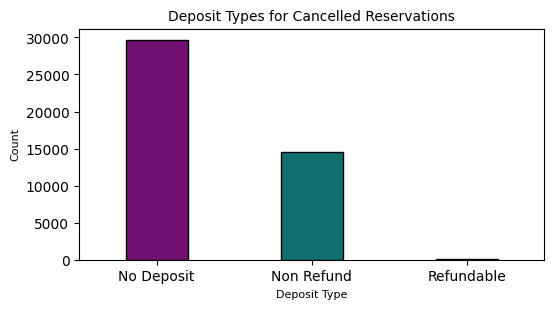

In [37]:
# Set font size for labels and percentages
plt.rcParams['font.size'] = 10
plt.figure(figsize=(6,3))
sns.countplot(data=cancelled_df, x='deposit_type', palette=["purple", "teal","gold"], edgecolor="black",width=0.4)
plt.title('Deposit Types for Cancelled Reservations', fontsize=10)
plt.xlabel('Deposit Type', fontsize=8)
plt.ylabel('Count', fontsize=8)
plt.show()

The chart indicates that the highest number of cancelled reservations falls under the category "No Deposit," possibly due to the absence of a deposit requirement. Following that, there are fewer cancellations in the "Non Refundable" category, and finally, the "Refundable" category has the lowest number of cancellations. It appears that guests tend to prefer refundable options over non-deposit or non-refundable choices.

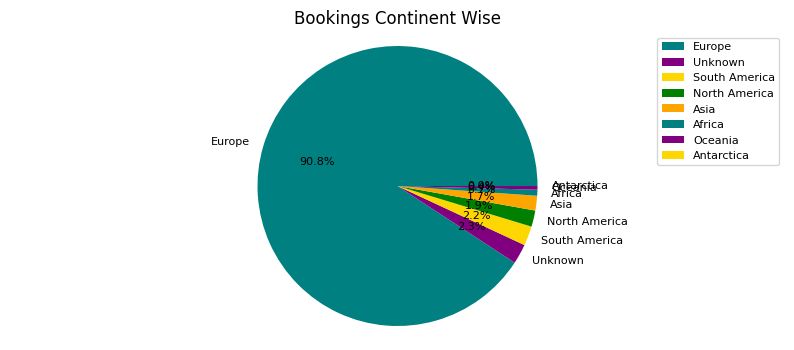

In [38]:
plt.rcParams['font.size'] = 8  # Adjust font size for labels and percentages

plt.figure(figsize=(10,4))  # Adjust figure size
continent_counts = df1['continent'].value_counts(normalize=True)
continent_counts.plot(kind='pie', autopct='%1.1f%%', colors=['teal', 'purple', 'gold', 'green', 'orange'])

plt.title("Bookings Continent Wise", fontsize=12)  # Adjust title font size
plt.ylabel("")  # Remove y-axis label
plt.axis('equal')  # Ensure pie chart is drawn as a circle

# Add labels
plt.legend(labels=continent_counts.index, loc="best", fontsize=8)

plt.show()

Most Data are of the european hotels

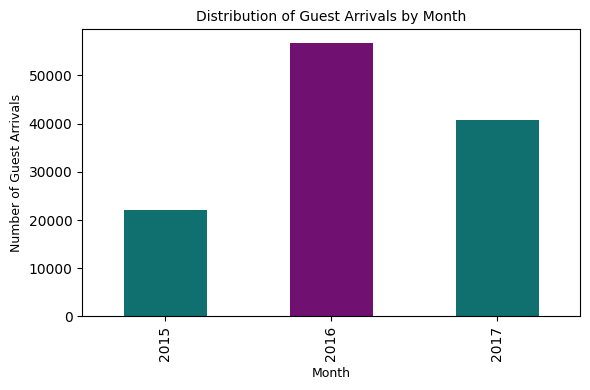

In [39]:
yearly_guest_arrivals = df1.groupby('arrival_date_year')['is_canceled'].count()

# Set font size for labels and percentages
plt.rcParams['font.size'] = 10
# Creating the bar plot for monthly guest arrivals
plt.figure(figsize=(6,4))
sns.barplot(x=yearly_guest_arrivals.index, y=yearly_guest_arrivals.values, palette=['teal', 'purple'],width=0.5)
plt.xlabel("Month", fontsize=9)
plt.ylabel("Number of Guest Arrivals",fontsize=9)
plt.title("Distribution of Guest Arrivals by Month",fontsize=10)
plt.xticks(rotation=90)
plt.tight_layout()

# Displaying the plot
plt.show()

There was a rise of booking in 2016 from 2015 and then 2017 it got lowered to 40000 bookings

In [40]:
import plotly.express as px

# Filter and group data for non-canceled bookings by country
top_countries = df1[df1['is_canceled'] == 0].groupby(['country']).size().reset_index(name='count')

# Create choropleth map using Plotly Express
fig = px.choropleth(top_countries,
                    locations="country",
                    color="count",
                    hover_name="country",
                    color_continuous_scale=["white", "gold", "olive", "purple"],
                    projection='orthographic',
                    title="Top Origin Countries of Visitors"
             )

# Show the plot
fig.show()

Based on the chart output, we can identify the top countries from which customers are arriving. The highest number of customers come from countries such as Portugal (PRT), Germany (DEU), United Kingdom (GBR), France (FRA), and Spain (FSp), all of which are European countries. This chart indicates that there are likely geographical preferences for customer arrivals at this hotel from these countries.

## Encoding Categorical Vairables

#### Ordinal Encoding

It is a technique used to transform categorical values into numerical values when those categorical values have a natural order. For example, the months of the year have a natural order (January, February, March, etc.), so we use ordinal encoding to assign a numerical value to each month, reflecting their order.

In [17]:
# Define the order of months
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Create a dictionary mapping each month to an ordinal number
month_to_ordinal = {month: i+1 for i, month in enumerate(months)}

# Apply the mapping to the DataFrame
df_cat['arrival_date_month'] = df_cat['arrival_date_month'].map(month_to_ordinal)

#### Label Encoding

The reserved room types and assigned room types in the hotel dataset (A,B,C,.....etc) were encoded using LabelEncoder for machine learning model compatibility.

In [18]:
label_encoder = LabelEncoder()
df_cat['reserved_room_type'] = label_encoder.fit_transform(df_cat['reserved_room_type'])
df_cat['assigned_room_type'] = label_encoder.fit_transform(df_cat['assigned_room_type'])

In [19]:
df_cat.head()

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,is_repeated_guest,continent
0,Resort Hotel,7,BB,Direct,Direct,2,2,No Deposit,Transient,0,Europe
1,Resort Hotel,7,BB,Direct,Direct,2,2,No Deposit,Transient,0,Europe
2,Resort Hotel,7,BB,Direct,Direct,0,2,No Deposit,Transient,0,Europe
3,Resort Hotel,7,BB,Corporate,Corporate,0,0,No Deposit,Transient,0,Europe
4,Resort Hotel,7,BB,Online TA,TA/TO,0,0,No Deposit,Transient,0,Europe


In [19]:
# added converted columns to numerical dataframe df_num
df_num['arrival_date_month'] = df_cat['arrival_date_month']
df_num['reserved_room_type'] = df_cat['reserved_room_type']
df_num['assigned_room_type'] = df_cat['assigned_room_type']
df_num.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month,reserved_room_type,assigned_room_type
0,0,342,2015,27,1,0,0,2,0.0,0,0,0,3,0,0.0,0,0,7,2,2
1,0,737,2015,27,1,0,0,2,0.0,0,0,0,4,0,0.0,0,0,7,2,2
2,0,7,2015,27,1,0,1,1,0.0,0,0,0,0,0,75.0,0,0,7,0,2
3,0,13,2015,27,1,0,1,1,0.0,0,0,0,0,0,75.0,0,0,7,0,0
4,0,14,2015,27,1,0,2,2,0.0,0,0,0,0,0,98.0,0,1,7,0,0


In [37]:
#df_cat.drop(['arrival_date_month','assigned_room_type','reserved_room_type'],axis=True,inplace=True)

In [21]:
df_cat.columns

Index(['hotel', 'arrival_date_month', 'meal', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'is_repeated_guest', 'continent'],
      dtype='object')

hotel


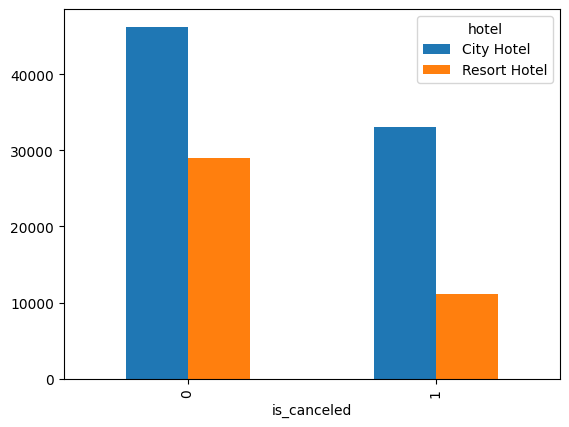

arrival_date_month


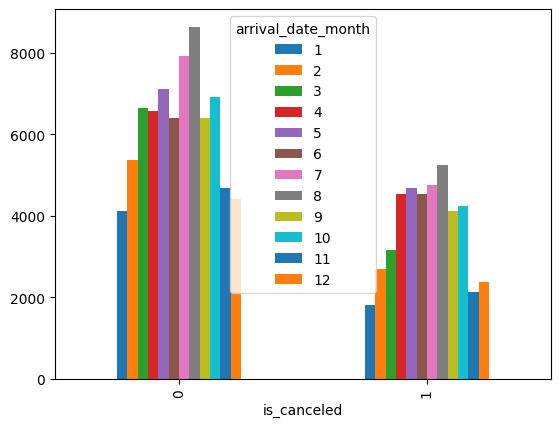

meal


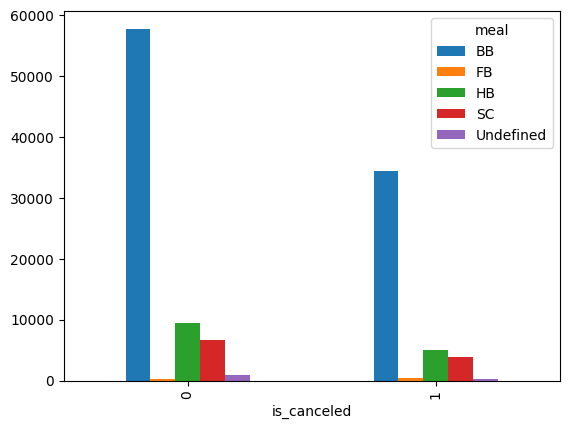

market_segment


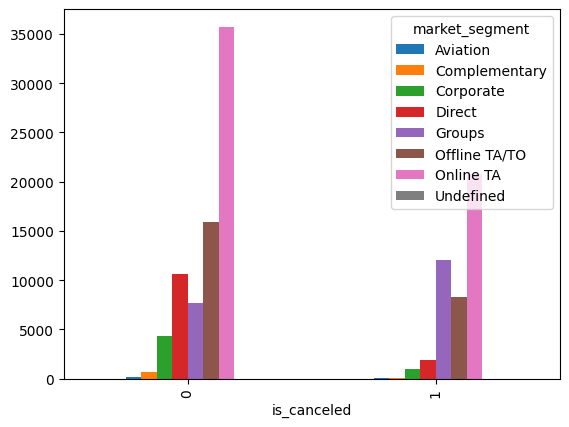

distribution_channel


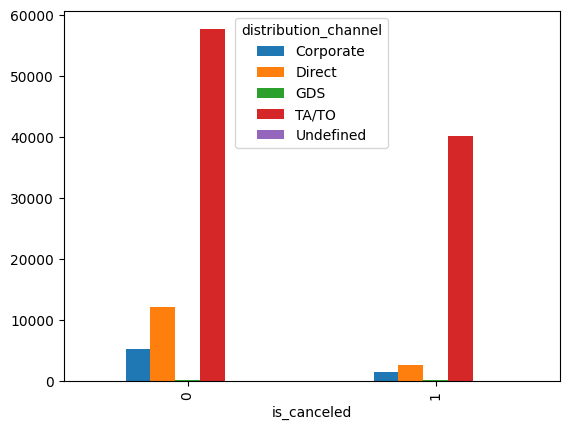

reserved_room_type


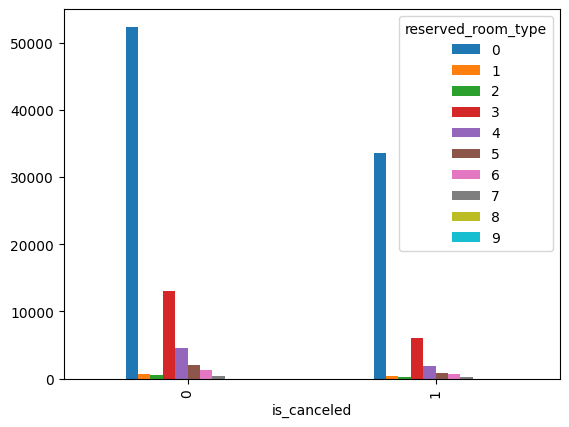

assigned_room_type


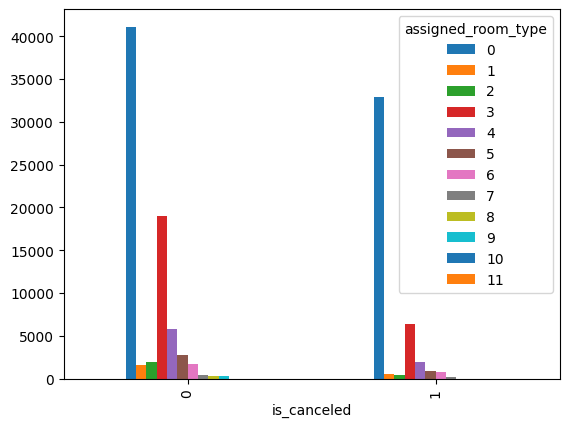

deposit_type


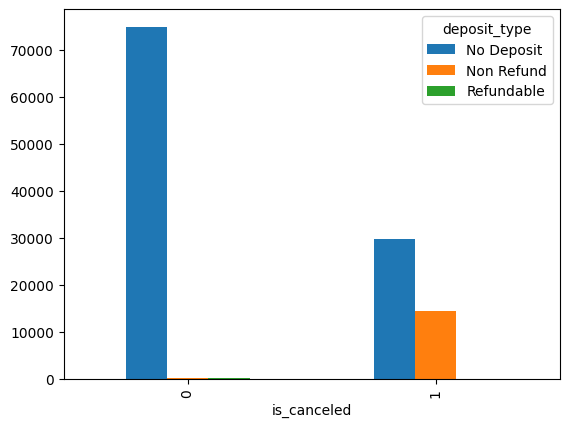

customer_type


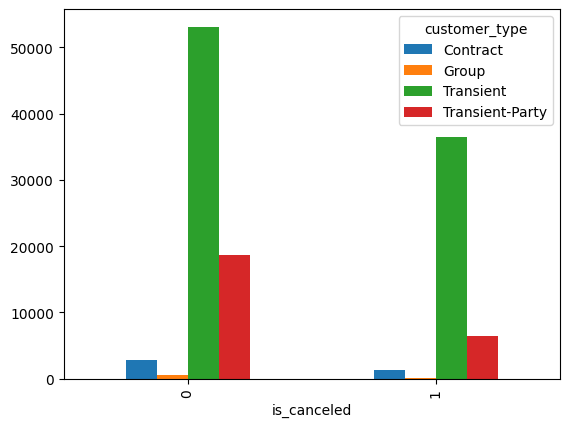

is_repeated_guest


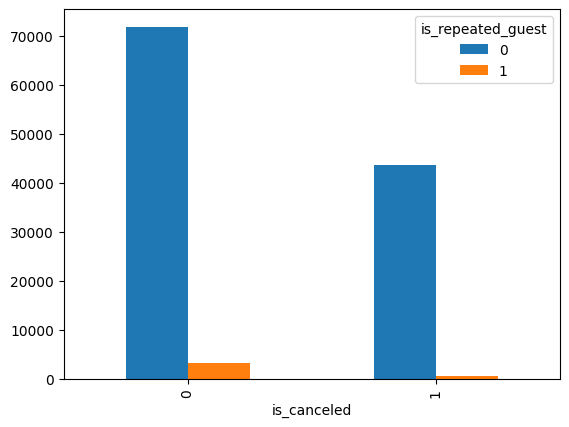

continent


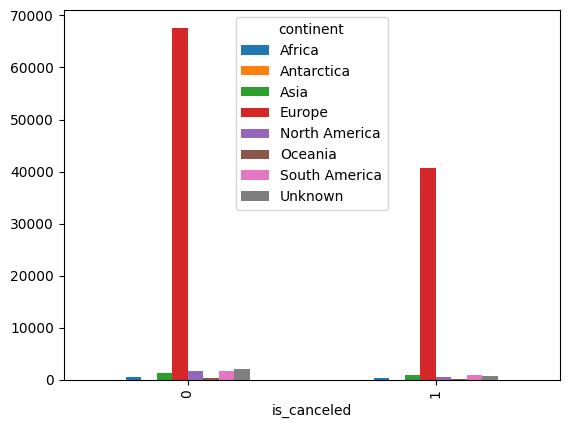

In [39]:
for i in df_cat.columns:
    print(i)
    pd.crosstab(df['is_canceled'],df_cat[i]).plot(kind='bar')
    plt.show()

In [22]:
from scipy.stats import chi2_contingency
chi2_contingency(pd.crosstab(df_cat['market_segment'],df_cat['distribution_channel']))

Chi2ContingencyResult(statistic=228659.92234098696, pvalue=0.0, dof=28, expected_freq=array([[1.32544518e+01, 2.90716559e+01, 3.83122540e-01, 1.94280844e+02,
        9.92545439e-03],
       [4.15529860e+01, 9.11402546e+01, 1.20109724e+00, 6.09074546e+02,
        3.11165089e-02],
       [2.96127942e+02, 6.49512313e+02, 8.55963649e+00, 4.34057836e+03,
        2.21752241e-01],
       [7.05002613e+02, 1.54631770e+03, 2.03782394e+01, 1.03337735e+04,
        5.27933663e-01],
       [1.10794913e+03, 2.43012057e+03, 3.20254879e+01, 1.62400751e+04,
        8.29675852e-01],
       [1.35447075e+03, 2.97082884e+03, 3.91512438e+01, 1.98535349e+04,
        1.01428093e+00],
       [3.15853027e+03, 6.92776334e+03, 9.12979395e+01, 4.62970432e+04,
        2.36523159e+00],
       [1.11851914e-01, 2.45330430e-01, 3.23310160e-03, 1.63950080e+00,
        8.37591088e-05]]))

#### One-Hot Encoding

In [20]:
df_cat = pd.get_dummies(data=df_cat,
                        columns=['hotel', 'meal', 'market_segment','distribution_channel',
                                 'deposit_type', 'customer_type', 'continent','arrival_date_month','assigned_room_type','reserved_room_type','arrival_date_month','assigned_room_type','reserved_room_type'],
                        dtype=int,
                        drop_first=True)

In [42]:
df_cat.head()

,is_repeated_guest,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,...,assigned_room_type_11,reserved_room_type_1,reserved_room_type_2,reserved_room_type_3,reserved_room_type_4,reserved_room_type_5,reserved_room_type_6,reserved_room_type_7,reserved_room_type_8,reserved_room_type_9
0,0,1,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
df_cat.shape

(119390, 91)

## Scaling Numeric Variables

In [21]:
min_max_scale = MinMaxScaler()
for c in df_num.drop('is_canceled',axis=1).columns:
    df_num[c] = min_max_scale.fit_transform(df_num[[c]])

In [22]:
df_num.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month,reserved_room_type,assigned_room_type
0,0,0.464043,0.0,0.5,0.0,0.0,0.00,0.036364,0.0,0.0,0.0,0.0,0.142857,0.0,0.001180,0.0,0.0,0.545455,0.222222,0.181818
1,0,1.000000,0.0,0.5,0.0,0.0,0.00,0.036364,0.0,0.0,0.0,0.0,0.190476,0.0,0.001180,0.0,0.0,0.545455,0.222222,0.181818
2,0,0.009498,0.0,0.5,0.0,0.0,0.02,0.018182,0.0,0.0,0.0,0.0,0.000000,0.0,0.015053,0.0,0.0,0.545455,0.000000,0.181818
3,0,0.017639,0.0,0.5,0.0,0.0,0.02,0.018182,0.0,0.0,0.0,0.0,0.000000,0.0,0.015053,0.0,0.0,0.545455,0.000000,0.000000
4,0,0.018996,0.0,0.5,0.0,0.0,0.04,0.036364,0.0,0.0,0.0,0.0,0.000000,0.0,0.019307,0.0,0.2,0.545455,0.000000,0.000000


In [23]:
# New dataframe with encoded and scaled variables for model building.
df_final = pd.concat([df_num,df_cat],axis=1)
df_final.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,assigned_room_type_11,reserved_room_type_1,reserved_room_type_2,reserved_room_type_3,reserved_room_type_4,reserved_room_type_5,reserved_room_type_6,reserved_room_type_7,reserved_room_type_8,reserved_room_type_9
0,0,0.464043,0.0,0.5,0.0,0.0,0.00,0.036364,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
1,0,1.000000,0.0,0.5,0.0,0.0,0.00,0.036364,0.0,0.0,...,0,0,1,0,0,0,0,0,0,0
2,0,0.009498,0.0,0.5,0.0,0.0,0.02,0.018182,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.017639,0.0,0.5,0.0,0.0,0.02,0.018182,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.018996,0.0,0.5,0.0,0.0,0.04,0.036364,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.0,0.000000,0.000000,1.000000,1.0
lead_time,119390.0,0.141128,0.144997,0.0,0.024423,0.093623,0.217096,1.0
arrival_date_year,119390.0,0.578277,0.353738,0.0,0.500000,0.500000,1.000000,1.0
arrival_date_week_number,119390.0,0.503176,0.261637,0.0,0.288462,0.519231,0.711538,1.0
arrival_date_day_of_month,119390.0,0.493275,0.292694,0.0,0.233333,0.500000,0.733333,1.0
...,...,...,...,...,...,...,...,...
reserved_room_type_5,119390.0,0.024265,0.153871,0.0,0.000000,0.000000,0.000000,1.0
reserved_room_type_6,119390.0,0.017539,0.131269,0.0,0.000000,0.000000,0.000000,1.0
reserved_room_type_7,119390.0,0.005034,0.070772,0.0,0.000000,0.000000,0.000000,1.0
reserved_room_type_8,119390.0,0.000050,0.007089,0.0,0.000000,0.000000,0.000000,1.0


## Spliting Dataset

In [25]:
X = df_final.drop(['is_canceled','arrival_date_month','reserved_room_type','assigned_room_type'],axis=1)
y = df_final['is_canceled']
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=100)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(95512, 107)
(23878, 107)
(95512,)
(23878,)


## Statistical Test

In [50]:
y_train.value_counts(normalize=True)*100

is_canceled
0    62.979521
1    37.020479
Name: proportion, dtype: float64

In [51]:
y_test.value_counts(normalize=True)*100

is_canceled
0    62.873775
1    37.126225
Name: proportion, dtype: float64

In [52]:
import statsmodels.stats.weightstats as weightstats
weightstats.ztest(y_train,y_test)

(-0.3026440587746897, 0.7621611340491565)

In [52]:
## Creating a list to store f1 score of all the models.
model_name = []
f1_score_train = []
f1_score_test = []

## Logistic Regression

In [53]:
logistic = LogisticRegression()
logistic_model = logistic.fit(X_train,y_train)
train_pred = logistic_model.predict(X_train)
test_pred = logistic_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.80      0.92      0.86     60153
           1       0.82      0.60      0.69     35359

    accuracy                           0.80     95512
   macro avg       0.81      0.76      0.77     95512
weighted avg       0.81      0.80      0.79     95512

Testing report               precision    recall  f1-score   support

           0       0.79      0.92      0.85     15013
           1       0.82      0.59      0.69      8865

    accuracy                           0.80     23878
   macro avg       0.81      0.76      0.77     23878
weighted avg       0.80      0.80      0.79     23878

Training F1 - Score 0.6916411407230257
Testing F1 - Score 0.6887365328109696


In [54]:
model_name.append('Logistic Regression')
f1_score_train.append(0.69)
f1_score_test.append(0.69)

## Decision Tree 

In [32]:
decision = DecisionTreeClassifier()
dc_model = decision.fit(X_train,y_train)
train_pred = dc_model.predict(X_train)
test_pred = dc_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.99      1.00      0.99     60153
           1       0.99      0.99      0.99     35359

    accuracy                           0.99     95512
   macro avg       0.99      0.99      0.99     95512
weighted avg       0.99      0.99      0.99     95512

Testing report               precision    recall  f1-score   support

           0       0.87      0.86      0.86     15013
           1       0.76      0.78      0.77      8865

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878

Training F1 - Score 0.9896348043391832
Testing F1 - Score 0.770433229120143


In [55]:
model_name.append('Decision Tree')
f1_score_train.append(0.99)
f1_score_test.append(0.77)

## Random Forest

In [26]:
rf = RandomForestClassifier(random_state=10)
rf_model = rf.fit(X_train,y_train)
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.99      1.00      0.99     60153
           1       0.99      0.99      0.99     35359

    accuracy                           0.99     95512
   macro avg       0.99      0.99      0.99     95512
weighted avg       0.99      0.99      0.99     95512

Testing report               precision    recall  f1-score   support

           0       0.87      0.93      0.90     15013
           1       0.87      0.77      0.82      8865

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878

Training F1 - Score 0.9896486202887043
Testing F1 - Score 0.8187911430281268


In [56]:
model_name.append('Random Forest')
f1_score_train.append(0.98)
f1_score_test.append(0.82)

In [36]:
# feature importance
imp = rf.feature_importances_
df_imp = pd.DataFrame(zip(X_train,imp),columns=['column','importance'])
df_imp = df_imp.sort_values('importance',ascending=False)
df_imp

,column,importance
0,lead_time,1.401997e-01
33,deposit_type_Non Refund,1.081222e-01
13,adr,9.209684e-02
3,arrival_date_day_of_month,6.556405e-02
15,total_of_special_requests,6.495268e-02
...,...,...
38,continent_Antarctica,2.057698e-06
105,reserved_room_type_8,1.130866e-06
74,reserved_room_type_8,1.808363e-07
96,assigned_room_type_10,0.000000e+00


## KNeighbors Classifier

In [37]:
kn = KNeighborsClassifier()
kn_model = kn.fit(X_train,y_train)
train_pred = kn_model.predict(X_train)
test_pred = kn_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.88      0.92      0.90     60153
           1       0.85      0.78      0.82     35359

    accuracy                           0.87     95512
   macro avg       0.87      0.85      0.86     95512
weighted avg       0.87      0.87      0.87     95512

Testing report               precision    recall  f1-score   support

           0       0.84      0.88      0.86     15013
           1       0.77      0.71      0.74      8865

    accuracy                           0.82     23878
   macro avg       0.81      0.79      0.80     23878
weighted avg       0.81      0.82      0.81     23878

Training F1 - Score 0.8152591454405769
Testing F1 - Score 0.7416231441816795


In [57]:
model_name.append('KNeighbors Classifier')
f1_score_train.append(0.82)
f1_score_test.append(0.74)

## AdaBoost

In [39]:
ada = AdaBoostClassifier(random_state=10)
ada_model = ada.fit(X_train,y_train)
train_pred = ada_model.predict(X_train)
test_pred = ada_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.81      0.93      0.86     60153
           1       0.84      0.63      0.72     35359

    accuracy                           0.82     95512
   macro avg       0.82      0.78      0.79     95512
weighted avg       0.82      0.82      0.81     95512

Testing report               precision    recall  f1-score   support

           0       0.81      0.93      0.86     15013
           1       0.83      0.63      0.72      8865

    accuracy                           0.81     23878
   macro avg       0.82      0.78      0.79     23878
weighted avg       0.82      0.81      0.81     23878

Training F1 - Score 0.7155066364519262
Testing F1 - Score 0.7151593176697779


In [58]:
model_name.append('AdaBoost')
f1_score_train.append(0.72)
f1_score_test.append(0.72)

## Gradient Boosting Classifier

In [41]:
gboost = GradientBoostingClassifier(random_state=10)
gboost_model = gboost.fit(X_train,y_train)
train_pred = gboost_model.predict(X_train)
test_pred = gboost_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.80      0.94      0.87     60153
           1       0.86      0.61      0.71     35359

    accuracy                           0.82     95512
   macro avg       0.83      0.78      0.79     95512
weighted avg       0.82      0.82      0.81     95512

Testing report               precision    recall  f1-score   support

           0       0.80      0.94      0.86     15013
           1       0.85      0.61      0.71      8865

    accuracy                           0.82     23878
   macro avg       0.83      0.77      0.79     23878
weighted avg       0.82      0.82      0.81     23878

Training F1 - Score 0.7132299571098647
Testing F1 - Score 0.7099783222755042


In [59]:
model_name.append('Gradient Boosting')
f1_score_train.append(0.71)
f1_score_test.append(0.71)

In [60]:
df_report = pd.DataFrame(data = model_name,columns=['Model_Name'])
df_report['Training_F1_Score'] = f1_score_train
df_report['Testing_F1_Score'] = f1_score_test
df_report.set_index('Model_Name')

,Training_F1_Score,Testing_F1_Score
Model_Name,,
Logistic Regression,0.69,0.69
Decision Tree,0.99,0.77
Random Forest,0.98,0.82
KNeighbors Classifier,0.82,0.74
AdaBoost,0.72,0.72
Gradient Boosting,0.71,0.71


## cross_validation

- cross_val_score is a useful function in scikit-learn that helps you evaluate the performance of a machine learning model by splitting your dataset into multiple training and test sets (cross-validation). It returns an array of scores from each fold, which can be averaged to get an overall performance measure.

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(f1_score, average='weighted')

# Perform cross-validation with 5 folds
scores = cross_val_score(rf, X, y, cv=5, scoring=f1_scorer)

# Output the individual scores and their mean
print("Cross-validation scores:", scores)
print("Mean f1_score:", scores.mean())

Cross-validation scores: [0.58656157 0.5498034  0.39431126 0.35984769 0.44891988]
Mean f1_score: 0.4678887596059086


## hyperparameter tuning

In [61]:
Tuned_Model_Name=[]
Training_f1_Score=[]
Testing_f1_Score=[]

In [73]:
# Decision_Tree

from sklearn.model_selection import GridSearchCV

parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


GSCV = GridSearchCV(estimator = decision,param_grid=parameters,scoring=f1_score,n_jobs=-1)
GSCV.fit(X_train,y_train)

print('best_parameter:',GSCV.best_params_)

best_parameter: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [75]:
## Decision_Tree

decision_tuned_model = DecisionTreeClassifier(criterion= 'gini', max_depth=10, min_samples_leaf= 1, min_samples_split= 2)
dc_model = decision_tuned_model.fit(X_train,y_train)
train_pred = dc_model.predict(X_train)
test_pred = dc_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.81      0.94      0.87     60153
           1       0.85      0.63      0.72     35359

    accuracy                           0.82     95512
   macro avg       0.83      0.78      0.80     95512
weighted avg       0.83      0.82      0.81     95512

Testing report               precision    recall  f1-score   support

           0       0.81      0.93      0.86     15013
           1       0.84      0.62      0.72      8865

    accuracy                           0.82     23878
   macro avg       0.82      0.78      0.79     23878
weighted avg       0.82      0.82      0.81     23878

Training F1 - Score 0.7217140341437167
Testing F1 - Score 0.7170715905409782


In [62]:
Tuned_Model_Name.append('Decision_Tree')
Training_f1_Score.append(0.72)
Testing_f1_Score.append(0.72)

In [77]:
# Random_Forest

parameters = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30,],
    'min_samples_split': [2, 5, 10],
}


GSCV = GridSearchCV(estimator = rf,param_grid=parameters,scoring=f1_score,n_jobs=-1)
GSCV.fit(X_train,y_train)

print('best_parameter:',GSCV.best_params_)

best_parameter: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [80]:
## Random_Forest

rf_tuned = RandomForestClassifier(max_depth=10, min_samples_split=2, n_estimators= 100)
rf_model = rf_tuned.fit(X_train,y_train)
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.79      0.96      0.87     60153
           1       0.90      0.56      0.69     35359

    accuracy                           0.82     95512
   macro avg       0.85      0.76      0.78     95512
weighted avg       0.83      0.82      0.80     95512

Testing report               precision    recall  f1-score   support

           0       0.79      0.96      0.87     15013
           1       0.90      0.56      0.69      8865

    accuracy                           0.81     23878
   macro avg       0.84      0.76      0.78     23878
weighted avg       0.83      0.81      0.80     23878

Training F1 - Score 0.692930138467441
Testing F1 - Score 0.6891479322786567


In [63]:
Tuned_Model_Name.append('Random Forest')
Training_f1_Score.append(0.68)
Testing_f1_Score.append(0.68)

In [78]:
# KNN_Classifier

parameters = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


GSCV = GridSearchCV(estimator = kn,param_grid=parameters,scoring=f1_score,n_jobs=-1)
GSCV.fit(X_train,y_train)

print('best_parameter:',GSCV.best_params_)

best_parameter: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [82]:
# KNN Classifier

kn_tuned = KNeighborsClassifier(metric= 'euclidean', n_neighbors= 3, weights= 'uniform')
kn_model = kn_tuned.fit(X_train,y_train)
train_pred = kn_model.predict(X_train)
test_pred = kn_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.91      0.93      0.92     60153
           1       0.88      0.84      0.86     35359

    accuracy                           0.90     95512
   macro avg       0.89      0.88      0.89     95512
weighted avg       0.90      0.90      0.90     95512

Testing report               precision    recall  f1-score   support

           0       0.84      0.86      0.85     15013
           1       0.76      0.73      0.74      8865

    accuracy                           0.81     23878
   macro avg       0.80      0.80      0.80     23878
weighted avg       0.81      0.81      0.81     23878

Training F1 - Score 0.8581423366670053
Testing F1 - Score 0.7436931229121069


In [64]:
Tuned_Model_Name.append('KNearest Neighbors')
Training_f1_Score.append(0.85)
Testing_f1_Score.append(0.74)

In [93]:
# AdaBoost



param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

GSCV = GridSearchCV(estimator = ada,param_grid=param_grid,scoring=f1_score,n_jobs=-1)
GSCV.fit(X_train,y_train)

print('best_parameter:',GSCV.best_params_)

best_parameter: {'learning_rate': 0.01, 'n_estimators': 50}


In [94]:
ada_tuned_model = AdaBoostClassifier(learning_rate= 0.01, n_estimators= 50)
ada_model = ada_tuned_model.fit(X_train,y_train)
train_pred = ada_model.predict(X_train)
test_pred = ada_model.predict(X_test)

print('Training report',classification_report(y_train,train_pred))
print('Testing report',classification_report(y_test,test_pred))
print('Training F1 - Score',f1_score(y_train,train_pred))
print('Testing F1 - Score',f1_score(y_test,test_pred))

Training report               precision    recall  f1-score   support

           0       0.72      1.00      0.83     60153
           1       0.99      0.33      0.49     35359

    accuracy                           0.75     95512
   macro avg       0.86      0.66      0.66     95512
weighted avg       0.82      0.75      0.71     95512

Testing report               precision    recall  f1-score   support

           0       0.72      1.00      0.83     15013
           1       0.99      0.33      0.49      8865

    accuracy                           0.75     23878
   macro avg       0.85      0.66      0.66     23878
weighted avg       0.82      0.75      0.71     23878

Training F1 - Score 0.4929071226525447
Testing F1 - Score 0.49287652645861607


In [65]:
Tuned_Model_Name.append('AdaBoost Classifier')
Training_f1_Score.append(0.49)
Testing_f1_Score.append(0.49)

In [7]:
df_tuned_report = pd.DataFrame(Tuned_Model_Name,columns=['Tuned_models'])

df_tuned_report['Training_f1_Score'] = Training_f1_Score
df_tuned_report['Testing_f1_Score'] = Testing_f1_Score

df_tuned_report

,Tuned_models,Training_f1_Score,Testing_f1_Score
0,Decision_Tree,0.72,0.72
1,Random Forest,0.68,0.68
2,KNearest Neighbors,0.85,0.74
3,AdaBoost Classifier,0.49,0.49


- We decided to go with the Random Forest model before hyperparameter tuning because the tuning process did not yield better results. The initial Random Forest model provided a robust performance with an F1 score of 0.82 on the testing data, which was higher than the tuned models.






